In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ignore warnings

import warnings
warnings.filterwarnings('ignore')

# plotting parameters
plt.rc('axes', labelsize=10)
plt.rc('axes', labelweight='regular')
plt.rc('axes', titleweight='regular')
plt.rc('axes', linewidth=1)
plt.rc('xtick',labelsize=10,direction='in',top=True)
plt.rc('ytick',labelsize=10,direction='in',right=True)
plt.rcParams['xtick.major.pad']='10'
plt.rcParams['ytick.major.pad']='10'

paper_params = {'text.usetex' : True,
           'font.size' : 14,
           'font.family' : 'lmodern',
           'figure.dpi' : 200,
           }
plt.rcParams.update(paper_params)
## 3.5 x 3 inch figure size for single column in paper
## 7 x 3 inch figure size for two column in paper


In [2]:
# read the mass_sweep files for the mantle temperature evolution for different planet masses 
data_dir = '/Users/dimoff/Radiogenic_Heating/planet_models/thermal_evolution_Foley_Unterborn/mass_sweep/'
list_files = !ls {data_dir}*mantle_temp*
list_files

['/Users/dimoff/Radiogenic_Heating/planet_models/thermal_evolution_Foley_Unterborn/mass_sweep/Earth_mantle_temp_0.10m.dat',
 '/Users/dimoff/Radiogenic_Heating/planet_models/thermal_evolution_Foley_Unterborn/mass_sweep/Earth_mantle_temp_0.20m.dat',
 '/Users/dimoff/Radiogenic_Heating/planet_models/thermal_evolution_Foley_Unterborn/mass_sweep/Earth_mantle_temp_0.30m.dat',
 '/Users/dimoff/Radiogenic_Heating/planet_models/thermal_evolution_Foley_Unterborn/mass_sweep/Earth_mantle_temp_0.40m.dat',
 '/Users/dimoff/Radiogenic_Heating/planet_models/thermal_evolution_Foley_Unterborn/mass_sweep/Earth_mantle_temp_0.50m.dat',
 '/Users/dimoff/Radiogenic_Heating/planet_models/thermal_evolution_Foley_Unterborn/mass_sweep/Earth_mantle_temp_0.60m.dat',
 '/Users/dimoff/Radiogenic_Heating/planet_models/thermal_evolution_Foley_Unterborn/mass_sweep/Earth_mantle_temp_0.70m.dat',
 '/Users/dimoff/Radiogenic_Heating/planet_models/thermal_evolution_Foley_Unterborn/mass_sweep/Earth_mantle_temp_0.80m.dat',
 '/Users

In [8]:
masses = []
times = []
mantle_temps = []
for file in list_files:
    mass = float(file.split('_')[-1].split('.dat')[0][:-1])
    masses.append(mass)
    data = np.loadtxt(file)
    times.append(data[:,0])
    mantle_temps.append(data[:,1])

Text(0, 0.5, 'Mantle Temperature (K)')

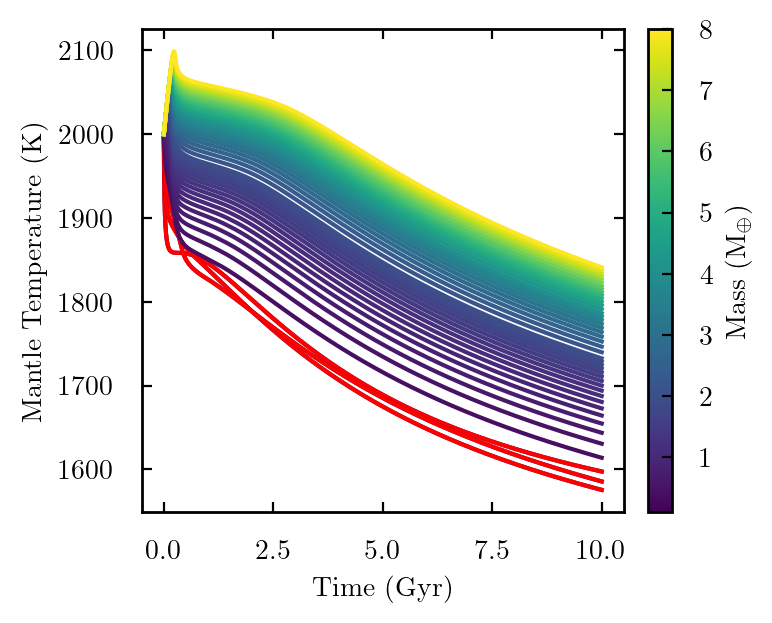

In [18]:
# make color bar based on mass
cmap = plt.get_cmap('viridis')
norm = plt.Normalize(vmin=np.min((masses)), vmax=np.max((masses)))

fig, ax = plt.subplots(figsize=(3.75,3), constrained_layout=True)
for mass, time_arr, mantle_temp_arr in zip(masses, times, mantle_temps):

    ax.plot(time_arr, mantle_temp_arr, color=cmap(norm(mass)))

    if mass < 0.4: 
        ax.plot(time_arr, mantle_temp_arr, color='red')

fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Mass (M$_\oplus$)')

ax.set_xlabel('Time (Gyr)')
ax.set_ylabel('Mantle Temperature (K)')